### Фактический запуск 14.09.2026

Все вычислительные ячейки выполнены. Техническое исполнение не подтверждает научные интерпретации исторического текста. Полный журнал — `legacy-execution.json`.

## Статус воспроизведения исторической редакции

Повторный технический запуск не подтверждает научные выводы старой редакции. Ниже сохранены прежние допущения и интерпретации; их следует сверять с текущими правилами проекта. Дыхательная и ЭКГ-разметка исторических расчётов не получает статус принятой при повторном запуске. Значения толщины 15 и 40 мм — исторические сценарии, а не заново проверенные измерения по КТ. Старые оценки сердечного происхождения сигнала и функций сердца не считаются валидированными.

In [1]:
import json
from pathlib import Path
_here = Path.cwd().resolve()
_repo = next(p for p in [_here, *_here.parents] if (p / "HnL" / "prototype.ipynb").is_file())
_config = json.loads((_repo / "HnL/config/prototype_paths.local.json").read_text(encoding="utf-8"))

In [2]:
import os
import re
import html
from pathlib import Path
import tkinter as tk
from tkinter import filedialog

import pandas as pd
import numpy as np
import altair as alt
import ipywidgets as widgets
from IPython.display import display, clear_output

alt.data_transformers.disable_max_rows()

fs_widget = widgets.BoundedFloatText(
    value=_config["sample_rate_hz"],
    min=1,
    max=20000,
    step=1,
    description='fs, Гц:',
    layout=widgets.Layout(width='180px')
)

In [3]:
def extract_number(name):
    numbers = re.findall(r'\d+', str(name))
    return int(numbers[0]) if numbers else float('inf')

def generate_title_text(path):
    return Path(path).stem

def find_txt_files(folder):
    out = []
    folder = Path(folder).expanduser()
    if not folder.exists() or not folder.is_dir():
        return out

    for root, _, files in os.walk(folder):
        root_text = str(root).lower()
        if 'checkpoint' in root_text:
            continue
        for fn in files:
            fn_lower = fn.lower()
            if fn_lower.endswith('.txt') and 'checkpoint' not in fn_lower:
                out.append(str(Path(root) / fn))
    return sorted(out)

def read_txt_safely(path, delimiter='\t'):
    encodings = ['utf-8', 'utf-8-sig', 'cp1251', 'latin1', 'ascii']
    last_error = None
    for enc in encodings:
        try:
            return pd.read_csv(path, delimiter=delimiter, encoding=enc).dropna(axis=1, how='all')
        except (OSError, UnicodeDecodeError, pd.errors.ParserError, ValueError) as e:
            last_error = e
    raise ValueError(f'Не удалось прочитать файл {path}: {last_error}') from last_error

def is_ecg_column(col_name):
    return str(col_name).startswith('ЭКГ')

In [4]:
def get_annotation_chart(lines):
    height = max(60, 18 * len(lines))
    df = pd.DataFrame({
        'y': [i * 0.2 for i in range(len(lines))][::-1],
        'text': lines,
    })
    return alt.Chart(df).mark_text(
        align='left',
        baseline='top',
        fontSize=12,
        color='gray',
    ).encode(
        y=alt.Y('y', axis=None),
        text='text:N',
    ).properties(
        width=230,
        height=height,
    )

def get_comment_annotation():
    comments = [
        'Назначение каналов в этой записи',
        '5 — горизонтальный',
        '7 — мягкие ткани',
        '9 — вертикальный',
        '13 — лёгкое',
        '16 — ЭКГ',
        '32 — трансторакальный',
    ]
    return get_annotation_chart(comments)

def get_mean_annotation(df, columns):
    text_lines = [f'{col}: {df[col].mean():.2f}' for col in columns if col in df.columns]
    if not text_lines:
        return None
    return get_annotation_chart(['Медианы:'] + text_lines)

In [5]:
state = {}

def _normalize_columns(df):
    df = df.copy()
    df.columns = [str(col) for col in df.columns]
    return df

def load_file(file_path):
    df = _normalize_columns(read_txt_safely(file_path, delimiter='\t'))
    sample_rate = float(fs_widget.value)
    time = np.arange(len(df)) / sample_rate

    checkboxes = []
    hidden_B_columns = []

    for col in df.columns:
        is_hidden = col.startswith('Б')
        checkboxes.append(widgets.Checkbox(value=not is_hidden, description=col))
        if is_hidden:
            hidden_B_columns.append(col)

    return {
        'path': file_path,
        'df': df,
        'time': time,
        'checkboxes': checkboxes,
        'hidden_B_columns': hidden_B_columns,
    }

def set_state(new_state):
    state.clear()
    state.update(new_state)
    return state

def get_long_df(current_state, invert_ecg=False):
    df = current_state.get('df')
    if df is None:
        return pd.DataFrame()

    selected_signals = [cb.description for cb in current_state.get('checkboxes', []) if cb.value]
    long_data = []

    for col in selected_signals:
        if col not in df.columns:
            continue
        signal = df[col].copy()
        if invert_ecg and is_ecg_column(col):
            signal = -signal
        long_data.append(pd.DataFrame({
            'Time': current_state['time'],
            'Value': signal,
            'Signal': col,
        }))

    return pd.concat(long_data, ignore_index=True) if long_data else pd.DataFrame()

In [6]:
folder_widget = widgets.Text(
    value=_config["data_root"],
    description='Папка:',
    layout=widgets.Layout(width='80%'),
)
choose_folder_button = widgets.Button(description='Выбрать папку')
rescan_button = widgets.Button(description='Пересканировать')
file_dropdown = widgets.Dropdown(options=[], description='Файл:', disabled=True)
checkbox_box_holder = widgets.VBox([])
files_box = widgets.VBox(
    [],
    layout=widgets.Layout(
        max_height='250px',
        overflow='auto',
        border='1px solid gray',
        padding='10px',
        width='100%',
    ),
)
files_state = {'txt_files': [], 'file_checkboxes': []}
ui_state = {'suspend_dropdown_observer': False}

def choose_folder(_):
    try:
        root = tk.Tk()
        root.withdraw()
        root.attributes('-topmost', True)
        root.update()
        folder = filedialog.askdirectory(
            initialdir=folder_widget.value or str(Path.cwd()),
            title='Выберите папку с TXT-файлами',
        )
        root.destroy()
    except Exception as e:
        with plot_output:
            clear_output(wait=True)
            display(widgets.HTML(
                f"<span style='color:#b00020'>Не удалось открыть выбор папки: {html.escape(str(e))}</span>"
            ))
        return

    if folder:
        folder_widget.value = folder
        on_rescan_clicked(None)

def sync_file_controls_enabled():
    has_files = bool(files_state['txt_files'])
    file_dropdown.disabled = not has_files
    for widget_name in ('invert_ecg_checkbox', 'altair_button', 'build_all_filtered_button'):
        widget = globals().get(widget_name)
        if widget is not None:
            widget.disabled = not has_files

def rescan(folder):
    txt_files = find_txt_files(folder)
    file_checkboxes = [
        widgets.Checkbox(
            value=True,
            description=generate_title_text(fp),
            layout=widgets.Layout(width='100%'),
        )
        for fp in txt_files
    ]

    files_state['txt_files'] = txt_files
    files_state['file_checkboxes'] = file_checkboxes
    files_box.children = file_checkboxes or [widgets.HTML('<i>В папке нет TXT-файлов</i>')]

    ui_state['suspend_dropdown_observer'] = True
    try:
        file_dropdown.options = [(generate_title_text(p), p) for p in txt_files]
        file_dropdown.value = next(iter(txt_files), None)
    finally:
        ui_state['suspend_dropdown_observer'] = False

    checkbox_box_holder.children = []
    state.clear()
    sync_file_controls_enabled()
    return txt_files

rescan(folder_widget.value)

['D:\\Аспа\\Bitrix\\ЭИТЛ\\01 Project\\01 Experiments\\EXP_2025_01_23_BMSTU_REO32_NIX (спина)\\Signals\\лёжа\\вдох.txt',
 'D:\\Аспа\\Bitrix\\ЭИТЛ\\01 Project\\01 Experiments\\EXP_2025_01_23_BMSTU_REO32_NIX (спина)\\Signals\\лёжа\\выдох.txt',
 'D:\\Аспа\\Bitrix\\ЭИТЛ\\01 Project\\01 Experiments\\EXP_2025_01_23_BMSTU_REO32_NIX (спина)\\Signals\\лёжа\\медленное дыхание.txt',
 'D:\\Аспа\\Bitrix\\ЭИТЛ\\01 Project\\01 Experiments\\EXP_2025_01_23_BMSTU_REO32_NIX (спина)\\Signals\\лёжа\\свободное дыхание.txt',
 'D:\\Аспа\\Bitrix\\ЭИТЛ\\01 Project\\01 Experiments\\EXP_2025_01_23_BMSTU_REO32_NIX (спина)\\Signals\\сидя\\вдох.txt',
 'D:\\Аспа\\Bitrix\\ЭИТЛ\\01 Project\\01 Experiments\\EXP_2025_01_23_BMSTU_REO32_NIX (спина)\\Signals\\сидя\\выдох.txt',
 'D:\\Аспа\\Bitrix\\ЭИТЛ\\01 Project\\01 Experiments\\EXP_2025_01_23_BMSTU_REO32_NIX (спина)\\Signals\\сидя\\медленное дыхание.txt',
 'D:\\Аспа\\Bitrix\\ЭИТЛ\\01 Project\\01 Experiments\\EXP_2025_01_23_BMSTU_REO32_NIX (спина)\\Signals\\сидя\\свободное 

In [7]:
plot_output = widgets.Output()

def build_chart(long_df, title, df_source, hidden_columns):
    sorted_signals = sorted(long_df['Signal'].unique(), key=extract_number)
    selection = alt.selection_point(fields=['Signal'], bind='legend')

    chart = alt.Chart(long_df).mark_line().encode(
        x='Time',
        y='Value',
        color=alt.Color('Signal:N', sort=sorted_signals),
        opacity=alt.condition(selection, alt.value(1), alt.value(0.1)),
    ).add_params(selection).properties(
        width=600,
        height=400,
        title=title,
    ).interactive()

    annotation = get_comment_annotation()
    mean_annot = get_mean_annotation(df_source, hidden_columns)
    side_panel = alt.vconcat(annotation, mean_annot) if mean_annot is not None else annotation

    return alt.hconcat(chart, side_panel).resolve_legend(color='independent').configure_view(stroke=None)

def plot_single_file(file_path):
    with plot_output:
        clear_output(wait=True)
        if not file_path or 'df' not in state:
            display(widgets.HTML('<i>Сначала выберите файл.</i>'))
            return

        long_df = get_long_df(state, invert_ecg_checkbox.value)
        if long_df.empty:
            display(widgets.HTML('<i>Нет выбранных сигналов.</i>'))
            return

        chart_final = build_chart(
            long_df,
            generate_title_text(file_path),
            state['df'],
            state.get('hidden_B_columns', []),
        )
        display(chart_final)

In [8]:
def get_long_df_from_df(df_local, time_local, selected_signals, invert_ecg):
    long_data = []
    for col in selected_signals:
        if col not in df_local.columns:
            continue
        signal = df_local[col].copy()
        if invert_ecg and is_ecg_column(col):
            signal = -signal
        long_data.append(pd.DataFrame({
            'Time': time_local,
            'Value': signal,
            'Signal': col,
        }))
    return pd.concat(long_data, ignore_index=True) if long_data else pd.DataFrame()

def plot_multiple_files(selected_files, selected_signals, invert_ecg):
    with plot_output:
        clear_output(wait=True)
        if not selected_files:
            display(widgets.HTML('<i>Нет выбранных файлов.</i>'))
            return
        if not selected_signals:
            display(widgets.HTML('<i>Нет выбранных сигналов.</i>'))
            return

        for file_path in selected_files:
            display(widgets.HTML(f'<b>Файл: {html.escape(generate_title_text(file_path))}</b>'))
            try:
                df_local = _normalize_columns(read_txt_safely(file_path, delimiter='\t'))
                time_local = np.arange(len(df_local)) / float(fs_widget.value)
                long_df = get_long_df_from_df(df_local, time_local, selected_signals, invert_ecg)
                if long_df.empty:
                    display(widgets.HTML('<i>Нет данных для выбранных сигналов.</i>'))
                    continue

                hidden_B_local = [col for col in df_local.columns if col.startswith('Б')]
                chart_final = build_chart(
                    long_df,
                    generate_title_text(file_path),
                    df_local,
                    hidden_B_local,
                )
                display(chart_final)

            except (OSError, UnicodeDecodeError, pd.errors.ParserError, ValueError) as e:
                display(widgets.HTML(
                    f"<span style='color:#b00020'>Ошибка при обработке файла "
                    f"{html.escape(generate_title_text(file_path))}: {html.escape(str(e))}</span>"
                ))

In [9]:
invert_ecg_checkbox = widgets.Checkbox(value=False, description='Инвертировать ЭКГ')
altair_button = widgets.Button(description='Показать график')
build_all_filtered_button = widgets.Button(description='Построить все выбранные')

def refresh_single_plot(path=None):
    checkbox_box_holder.children = []
    if not path:
        state.clear()
        sync_file_controls_enabled()
        return

    try:
        set_state(load_file(path))
        checkbox_box_holder.children = state['checkboxes']
    except (OSError, UnicodeDecodeError, pd.errors.ParserError, ValueError) as e:
        state.clear()
        checkbox_box_holder.children = [widgets.HTML(
            f"<span style='color:#b00020'>Не удалось загрузить файл: {html.escape(str(e))}</span>"
        )]
        with plot_output:
            clear_output(wait=True)
            display(checkbox_box_holder.children[0])
    finally:
        sync_file_controls_enabled()

def selected_file_paths():
    return [
        fp for fp, cb in zip(files_state['txt_files'], files_state['file_checkboxes'])
        if cb.value
    ]

def selected_signal_names():
    return [cb.description for cb in state.get('checkboxes', []) if cb.value]

def on_rescan_clicked(_):
    files = rescan(folder_widget.value)
    if files:
        refresh_single_plot(file_dropdown.value)
        with plot_output:
            clear_output(wait=True)
    else:
        with plot_output:
            clear_output(wait=True)
            display(widgets.HTML('<i>В папке нет TXT-файлов</i>'))

def on_file_change(change):
    if change['name'] != 'value' or ui_state.get('suspend_dropdown_observer'):
        return
    refresh_single_plot(change['new'])

def on_fs_change(change):
    if change['name'] != 'value' or 'df' not in state:
        return
    state['time'] = np.arange(len(state['df'])) / float(change['new'])
    if file_dropdown.value:
        plot_single_file(file_dropdown.value)

choose_folder_button.on_click(choose_folder)
rescan_button.on_click(on_rescan_clicked)
file_dropdown.observe(on_file_change, names='value')
fs_widget.observe(on_fs_change, names='value')
altair_button.on_click(lambda _: plot_single_file(file_dropdown.value))
build_all_filtered_button.on_click(lambda _: plot_multiple_files(
    selected_file_paths(),
    selected_signal_names(),
    invert_ecg_checkbox.value,
))

sync_file_controls_enabled()
if file_dropdown.value:
    refresh_single_plot(file_dropdown.value)

controls = widgets.VBox([
    widgets.HBox([folder_widget, choose_folder_button, rescan_button]),
    fs_widget,
    file_dropdown,
    checkbox_box_holder,
    invert_ecg_checkbox,
    altair_button,
    widgets.HTML('<b>Файлы для общего просмотра:</b>'),
    files_box,
    build_all_filtered_button,
])

display(widgets.VBox([controls, plot_output]))

### Читательское представление загруженной записи

Интерактивные элементы требуют работающего ядра Jupyter. Для автономного HTML ниже сохранён график первых десяти секунд фактически загруженной записи. Частота дискретизации взята из локальной конфигурации; шкалы каналов показаны раздельно. Это технический просмотр, а не оценка функции сердца.

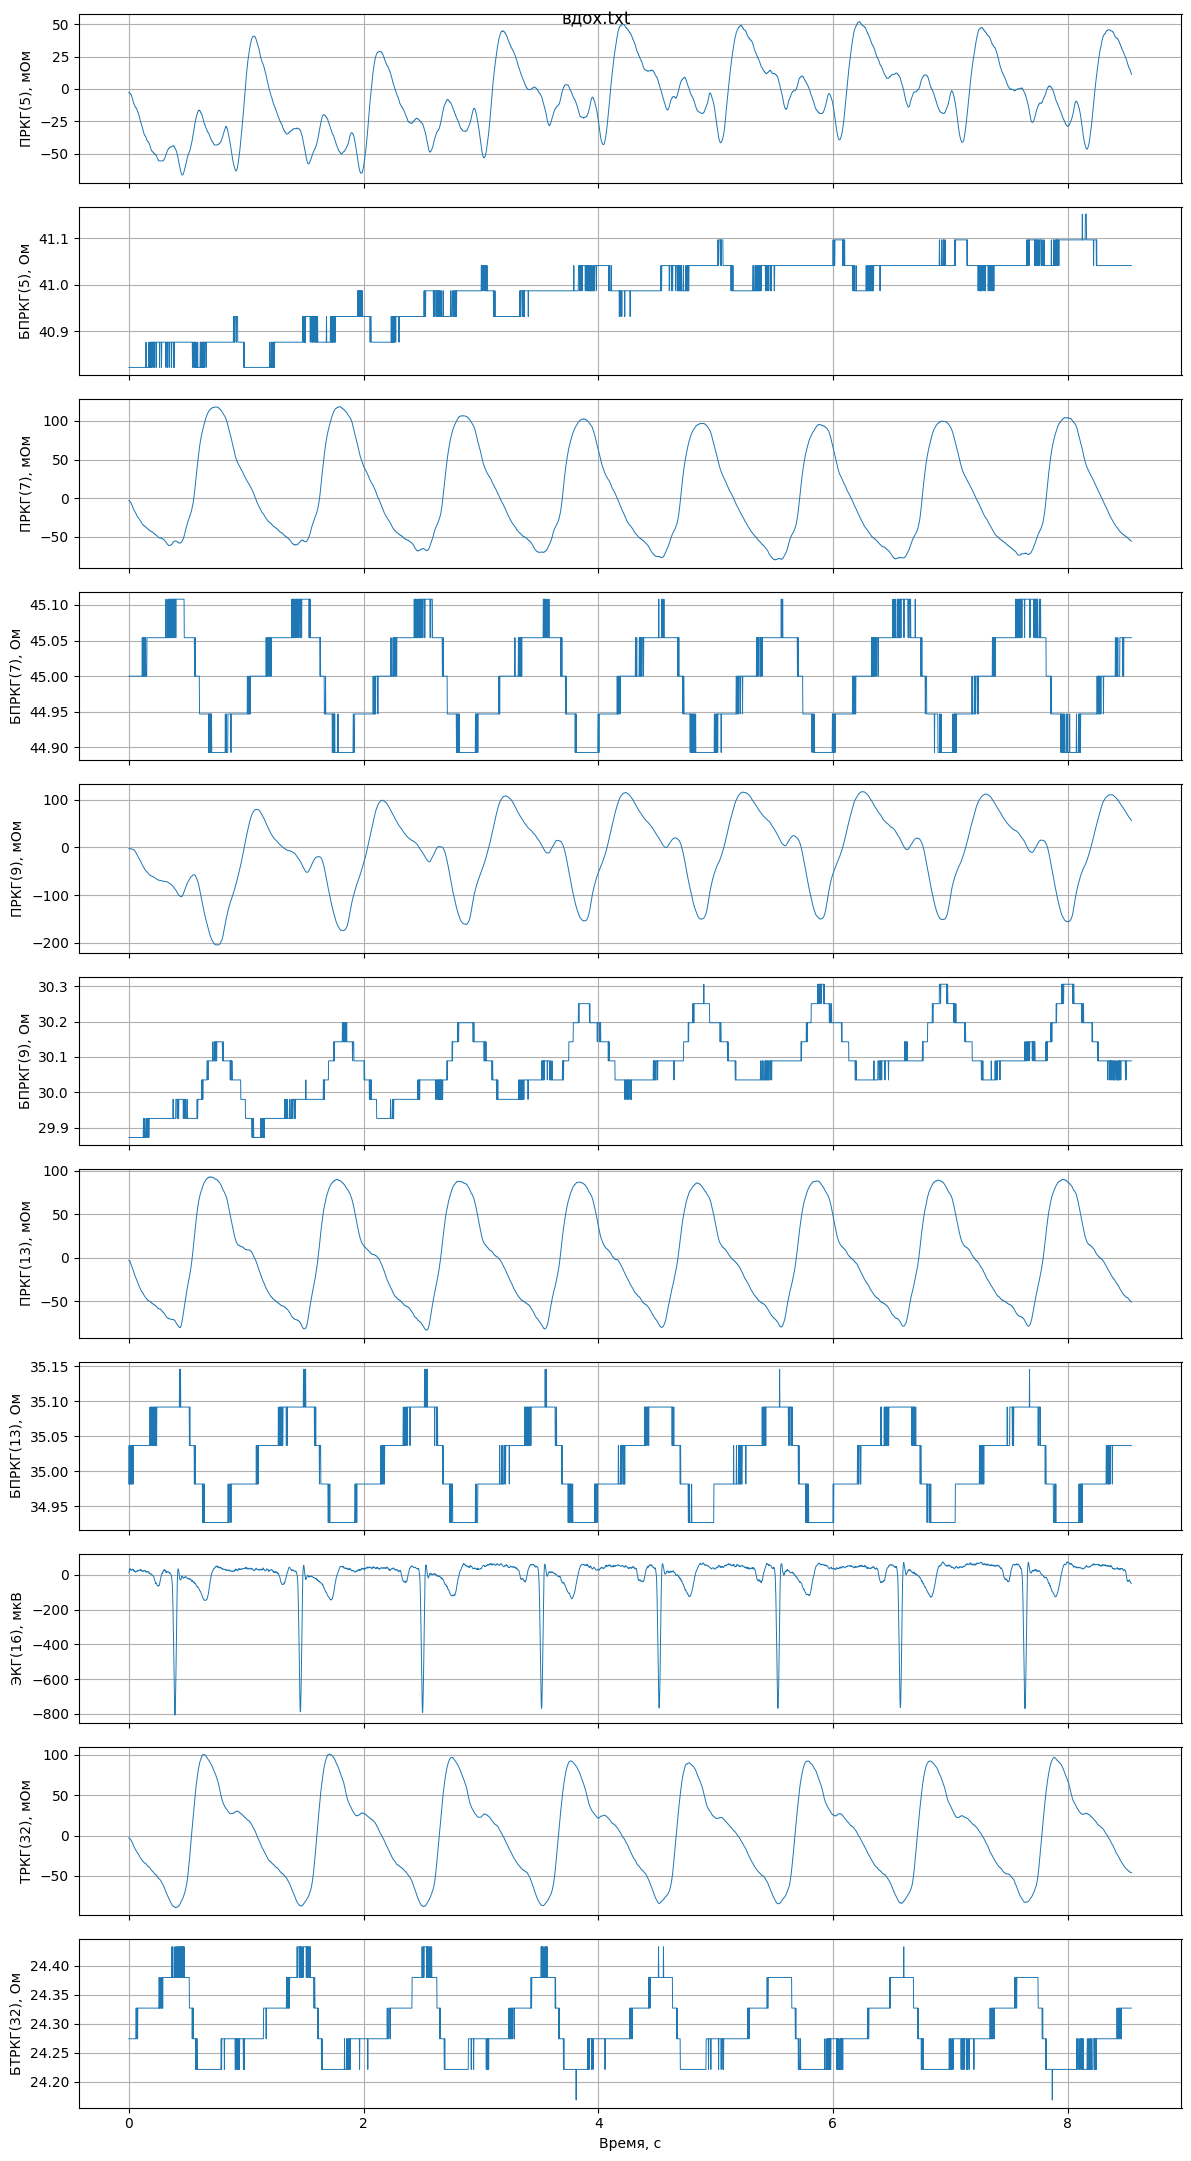

Строк в загруженной записи: 4273 ; числовых каналов: 11


In [10]:
import matplotlib.pyplot as plt
if not state or state.get("df") is None:
    raise RuntimeError("Нет загруженного TXT; проверьте локальную конфигурацию.")
_df = state["df"].select_dtypes(include="number")
_n = min(len(_df), int(float(fs_widget.value) * 10))
fig, axes = plt.subplots(len(_df.columns), 1, figsize=(12, max(3, 2*len(_df.columns))), sharex=True, squeeze=False)
for ax, col in zip(axes[:, 0], _df.columns):
    ax.plot(state["time"][:_n], _df[col].iloc[:_n], lw=.7)
    ax.set_ylabel(col); ax.grid(True)
axes[-1, 0].set_xlabel("Время, с")
fig.suptitle(Path(state["path"]).name)
plt.tight_layout(); plt.show()
print("Строк в загруженной записи:", len(_df), "; числовых каналов:", len(_df.columns))